# 05 - Neural Network (Person 1)

**Task:** same as Logistic Regression - prepaid within 24 months (`1`) or not (`0`), on the **same** processed data and test set.

**Architecture (feed-forward / multilayer perceptron):**

| Layer | Size | Activation | Why |
|---|---|---|---|
| Input | 20 features | - | one neuron per processed feature |
| Hidden 1 | 32 neurons | ReLU | learns non-linear combinations of features |
| Hidden 2 | 16 neurons | ReLU | a second, smaller layer |
| Output | 1 neuron | Sigmoid | outputs a probability between 0 and 1 for "Prepayment" |

- **Loss:** binary cross-entropy (the same log-loss that Logistic Regression minimises).
- **Optimizer:** Adam, learning rate 0.001 (gradient descent that adapts the step size per weight).
- **Batch size:** 64 samples per weight update. **Epochs:** at most 50 (one epoch = one pass over the training data).
- **Early stopping:** training stops when validation loss has not improved for 5 epochs, and the best weights are restored. This is our guard against overfitting.

In [1]:
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

PROC, METRICS, CM, PLOTS = "../data/processed", "../results/metrics", "../results/confusion_matrices", "../results/plots"
TAG = "neural_network"
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)   # reproducible results

C:\Users\uttam\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Load the processed data

In [2]:
X_train = pd.read_csv(f"{PROC}/X_train.csv")
X_test = pd.read_csv(f"{PROC}/X_test.csv")
y_train = pd.read_csv(f"{PROC}/y_train.csv")["target"]
y_test = pd.read_csv(f"{PROC}/y_test.csv")["target"]
print("Train:", X_train.shape, " Test:", X_test.shape)

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print("Majority-class baseline accuracy on test: %.4f" % baseline_acc)

Train: (39288, 20)  Test: (9823, 20)
Majority-class baseline accuracy on test: 0.5243


## 2. Validation set
The network needs a validation set to decide when to stop training. We take 15 % **of the training data** for this.
The test set stays untouched until the final evaluation.

In [3]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)
print("Fit:", X_fit.shape, " Validation:", X_val.shape)

Fit: (33394, 20)  Validation: (5894, 20)


## 3. Build the network

In [4]:
n_features = X_train.shape[1]

model = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),      # input layer
    keras.layers.Dense(32, activation="relu"),    # hidden layer 1
    keras.layers.Dense(16, activation="relu"),    # hidden layer 2
    keras.layers.Dense(1, activation="sigmoid"),  # output layer: probability of prepayment
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

Parameter count check: layer 1 has 20x32 weights + 32 biases = 672, layer 2 has 32x16 + 16 = 528, output has 16x1 + 1 = 17, total 1,217.

## 4. Train

In [5]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(X_fit, y_fit,
                    validation_data=(X_val, y_val),
                    epochs=50, batch_size=64,
                    callbacks=[early_stop], verbose=2)
epochs_run = len(history.history["loss"])
print("Epochs actually run:", epochs_run)

Epoch 1/50
522/522 - 3s - 6ms/step - accuracy: 0.6251 - loss: 0.6468 - val_accuracy: 0.6437 - val_loss: 0.6334
Epoch 2/50
522/522 - 1s - 2ms/step - accuracy: 0.6480 - loss: 0.6295 - val_accuracy: 0.6454 - val_loss: 0.6298
Epoch 3/50
522/522 - 1s - 2ms/step - accuracy: 0.6504 - loss: 0.6265 - val_accuracy: 0.6474 - val_loss: 0.6290
Epoch 4/50
522/522 - 1s - 2ms/step - accuracy: 0.6513 - loss: 0.6247 - val_accuracy: 0.6461 - val_loss: 0.6286
Epoch 5/50
522/522 - 1s - 2ms/step - accuracy: 0.6535 - loss: 0.6233 - val_accuracy: 0.6486 - val_loss: 0.6282
Epoch 6/50
522/522 - 1s - 2ms/step - accuracy: 0.6544 - loss: 0.6223 - val_accuracy: 0.6478 - val_loss: 0.6280
Epoch 7/50
522/522 - 1s - 2ms/step - accuracy: 0.6559 - loss: 0.6215 - val_accuracy: 0.6468 - val_loss: 0.6279
Epoch 8/50
522/522 - 1s - 2ms/step - accuracy: 0.6567 - loss: 0.6208 - val_accuracy: 0.6473 - val_loss: 0.6277
Epoch 9/50
522/522 - 1s - 2ms/step - accuracy: 0.6568 - loss: 0.6202 - val_accuracy: 0.6469 - val_loss: 0.6277
E

### Training curves
If the validation loss starts rising while the training loss keeps falling, the network is starting to overfit. Early stopping picks the best point.

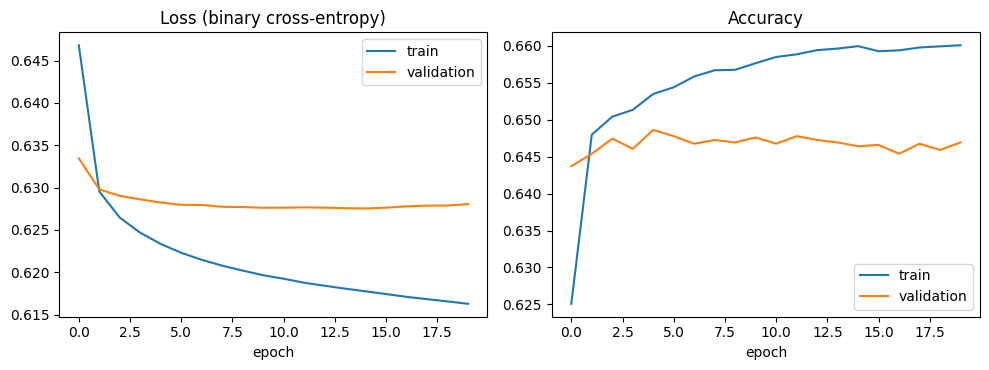

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(history.history["loss"], label="train"); ax[0].plot(history.history["val_loss"], label="validation")
ax[0].set_title("Loss (binary cross-entropy)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train"); ax[1].plot(history.history["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{PLOTS}/{TAG}_training_curves.png", dpi=150); plt.show()

## 5. Predict and evaluate (same metrics as Logistic Regression)

In [7]:
def get_metrics(y_true, y_pred, y_prob):
    """Same metric set for every model. Precision/recall/F1 are for class 1 (Prepayment)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred)),
        "recall": float(recall_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

train_prob = model.predict(X_train, verbose=0).ravel()
test_prob = model.predict(X_test, verbose=0).ravel()
train_pred = (train_prob >= 0.5).astype(int)      # usual 0.5 threshold
test_pred = (test_prob >= 0.5).astype(int)

train_metrics = get_metrics(y_train, train_pred, train_prob)
test_metrics = get_metrics(y_test, test_pred, test_prob)
print(pd.DataFrame({"train": train_metrics, "test": test_metrics}).round(4))

                train       test
accuracy       0.6588     0.6573
precision      0.6741     0.6756
recall         0.6763     0.6664
f1             0.6752     0.6710
roc_auc        0.7158     0.7094
tn         11953.0000  3025.0000
fp          6736.0000  1648.0000
fn          6668.0000  1718.0000
tp         13931.0000  3432.0000


## 6. Confusion matrix and ROC curve

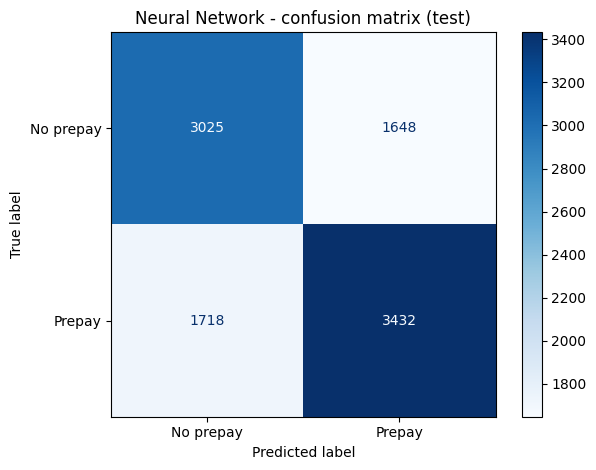

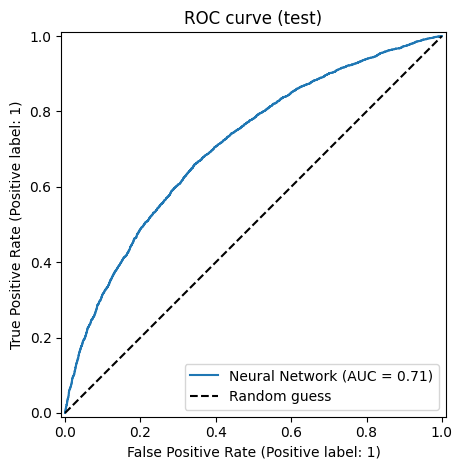

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["No prepay", "Prepay"], cmap="Blues")
plt.title("Neural Network - confusion matrix (test)")
plt.tight_layout(); plt.savefig(f"{PLOTS}/{TAG}_confusion_matrix.png", dpi=150); plt.show()

RocCurveDisplay.from_predictions(y_test, test_prob, name="Neural Network")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.legend(); plt.title("ROC curve (test)")
plt.tight_layout(); plt.savefig(f"{PLOTS}/{TAG}_roc_curve.png", dpi=150); plt.show()

## 7. Save results (shared format)

In [9]:
result = {
    "model": "Neural Network",
    "task": "Prepayment within 24 months (1) vs no prepayment (0)",
    "n_train": int(len(X_train)), "n_test": int(len(X_test)), "n_features": int(n_features),
    "split_seed": SEED,
    "hyperparameters": {"architecture": f"{n_features}-32(ReLU)-16(ReLU)-1(sigmoid)",
                        "loss": "binary_crossentropy", "optimizer": "Adam", "learning_rate": 0.001,
                        "batch_size": 64, "max_epochs": 50, "epochs_run": int(epochs_run),
                        "early_stopping": "val_loss, patience 5, restore best weights",
                        "validation_split": "15% of training data", "threshold": 0.5},
    "baseline_majority_accuracy_test": float(baseline_acc),
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
}
with open(f"{METRICS}/{TAG}_metrics.json", "w") as f:
    json.dump(result, f, indent=2)

pd.DataFrame({"y_true": y_test, "y_pred": test_pred, "y_prob": test_prob.round(6)}).to_csv(
    f"{METRICS}/{TAG}_test_predictions.csv", index=False)

cm = confusion_matrix(y_test, test_pred)
pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]).to_csv(
    f"{CM}/{TAG}_confusion_matrix.csv")
print("Saved results for", TAG)

Saved results for neural_network


## 8. Interpretation
(Numbers below are from our saved run, `results/metrics/neural_network_metrics.json`. Neural-network results can differ slightly between runs/machines even with fixed seeds.)

- **Training behaviour.** Validation loss flattens out after about 3 epochs (best value at epoch 10) while training loss keeps falling, so a small gap opens up (final loss about 0.618 train vs 0.628 validation). This is the start of mild overfitting, which early stopping handles: it ended training at epoch 15 and restored the best weights. With only 1,217 parameters and 33,000 training rows the gap stays small.
- **Test performance.** Accuracy is about 65.8 % (majority baseline 52.4 %), ROC-AUC about 0.71, F1 about 0.67. Train and test numbers are close.
- **Compared with Logistic Regression** (accuracy about 64.7 %, AUC about 0.70): the neural network is slightly higher, by roughly one percentage point. That is a small difference from a single run and one split, so we should not read much into it. A network can capture non-linear effects (such as the rise-then-fall of prepayment with interest rate), but the information in origination data is limited, so the gain is small.
- **Limitations:** a neural network is harder to interpret than Logistic Regression (no simple coefficients), depends on scaled inputs, and its result depends on the random initialisation and the chosen architecture. We did not tune the architecture.

No model is declared best here; that comparison waits until SVM and GDA are done.